# Trader Performance vs. Bitcoin Market Sentiment
**Primetrade.ai Data Science Assignment**

**Objective:** Explore the relationship between trader performance (Hyperliquid historical trade data)
and Bitcoin market sentiment (Fear & Greed Index), uncover patterns, and translate them into
actionable trading-strategy insights.

**Datasets**
- `fear_greed_index.csv` — daily Fear/Greed classification and index value
- `historical_data.csv` — Hyperliquid trade-level execution data (account, coin, side, size, closed PnL, fees, etc.)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Display settings
pd.set_option("display.max_columns", None)
plt.style.use("ggplot")

## 1. Load Data

In [2]:
# Read Fear & Greed Dataset
fear_df = pd.read_csv("fear_greed_index.csv")

# Read Historical Trading Dataset
trade_df = pd.read_csv("historical_data.csv")

## 2. Initial Data Overview

In [3]:
print("Fear & Greed Dataset")
display(fear_df.head())

print("\nHistorical Trading Dataset")
display(trade_df.head())

Fear & Greed Dataset


,timestamp,value,classification,date
0,1517463000,30,Fear,01-02-2018
1,1517549400,15,Extreme Fear,02-02-2018
2,1517635800,40,Fear,03-02-2018
3,1517722200,24,Extreme Fear,04-02-2018
4,1517808600,11,Extreme Fear,05-02-2018



Historical Trading Dataset


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [4]:
print("Fear & Greed Dataset")
fear_df.info()

print("\nHistorical Trading Dataset")
trade_df.info()

Fear & Greed Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB

Historical Trading Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-n

In [5]:
print("Fear Dataset Missing Values")
display(fear_df.isnull().sum())

print("\nTrading Dataset Missing Values")
display(trade_df.isnull().sum())

Fear Dataset Missing Values


timestamp         0
value             0
classification    0
date              0
dtype: int64


Trading Dataset Missing Values


Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [6]:
print("Fear Dataset Duplicates:", fear_df.duplicated().sum())
print("Trading Dataset Duplicates:", trade_df.duplicated().sum())

Fear Dataset Duplicates: 0
Trading Dataset Duplicates: 0


Both datasets are complete (no nulls) and free of exact duplicate rows, so no imputation or
de-duplication is required before merging.

## 3. Data Cleaning & Merge

In [7]:
# Convert Fear & Greed Date (DD-MM-YYYY)
fear_df["date"] = pd.to_datetime(
    fear_df["date"],
    format="%d-%m-%Y"
)

# Convert trade timestamp (epoch ms) to a plain date for joining
trade_df["Date"] = pd.to_datetime(
    trade_df["Timestamp"],
    unit="ms"
).dt.normalize()

In [8]:
# Rename Columns
fear_df = fear_df.rename(columns={
    "date": "Date",
    "classification": "Sentiment",
    "value": "FearGreedValue"
})

fear_df.head()

,timestamp,FearGreedValue,Sentiment,Date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


**Data quality check:** some values in `Coin` look like unresolved token IDs
(e.g. `@107`, `@109`, `@85`) rather than tickers like `AVAX` or `ETH`. Flagging this now so
it can be excluded/interpreted correctly in the coin-level analysis below, rather than silently
treated as a real coin.

In [9]:
# Inspect Coin column for placeholder/unresolved values
unresolved_coins = trade_df.loc[trade_df["Coin"].str.startswith("@"), "Coin"].unique()
print(f"{len(unresolved_coins)} unresolved coin codes found, e.g.: {unresolved_coins[:10]}")
print(f"Rows affected: {trade_df['Coin'].str.startswith('@').sum()} "
      f"({trade_df['Coin'].str.startswith('@').mean():.2%} of trades)")

# Check whether a leverage-related column exists under a different name
leverage_cols = [c for c in trade_df.columns if "lever" in c.lower()]
print("\nLeverage-related columns found:", leverage_cols if leverage_cols else "None")

77 unresolved coin codes found, e.g.: ['@107' '@7' '@19' '@21' '@44' '@48' '@11' '@15' '@46' '@61']
Rows affected: 33986 (16.09% of trades)

Leverage-related columns found: None


> **Action needed from you:** if the assignment brief's `leverage` field isn't present under
another name, note that explicitly in your write-up (data limitation) rather than omitting it silently.
If unresolved coin codes make up a small share of trades, it's reasonable to exclude them from the
coin-level ranking and mention that exclusion.

In [10]:
merged_df = trade_df.merge(
    fear_df,
    on="Date",
    how="left"
)

merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,timestamp,FearGreedValue,Sentiment
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27,1.730007e+09,74.0,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27,1.730007e+09,74.0,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27,1.730007e+09,74.0,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27,1.730007e+09,74.0,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27,1.730007e+09,74.0,Greed


In [11]:
print("Merged Dataset Shape:", merged_df.shape)
print("Unmatched sentiment rows:", merged_df["Sentiment"].isnull().sum())

Merged Dataset Shape: (211224, 20)
Unmatched sentiment rows: 26961


## 4. Exploratory Data Analysis

In [12]:
# Summary Statistics
merged_df.describe(include="all")

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,timestamp,FearGreedValue,Sentiment
count,211224,211224,211224.000000,2.112240e+05,2.112240e+05,211224,211224,2.112240e+05,211224,211224.000000,211224,2.112240e+05,211224,211224.000000,2.112240e+05,2.112240e+05,211224,1.842630e+05,184263.000000,184263
unique,32,246,NaN,NaN,NaN,2,27977,NaN,12,NaN,101184,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,4
top,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,NaN,NaN,NaN,SELL,14-02-2025 00:31,NaN,Open Long,NaN,0x00000000000000000000000000000000000000000000...,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,Fear
freq,40184,68005,NaN,NaN,NaN,108528,441,NaN,49895,NaN,9032,NaN,128403,NaN,NaN,NaN,NaN,NaN,NaN,133871
mean,NaN,NaN,11414.723350,4.623365e+03,5.639451e+03,NaN,NaN,-2.994625e+04,NaN,48.749001,NaN,6.965388e+10,NaN,1.163967,5.628549e+14,1.737744e+12,2025-01-24 01:44:11.425974528,1.735909e+09,51.623484,NaN
min,NaN,NaN,0.000005,8.740000e-07,0.000000e+00,NaN,NaN,-1.433463e+07,NaN,-117990.104100,NaN,1.732711e+08,NaN,-1.175712,0.000000e+00,1.680000e+12,2023-03-28 00:00:00,1.679981e+09,44.000000,NaN
25%,NaN,NaN,4.854700,2.940000e+00,1.937900e+02,NaN,NaN,-3.762311e+02,NaN,0.000000,NaN,5.983853e+10,NaN,0.016121,2.810000e+14,1.740000e+12,2025-02-19 00:00:00,1.730007e+09,44.000000,NaN
50%,NaN,NaN,18.280000,3.200000e+01,5.970450e+02,NaN,NaN,8.472793e+01,NaN,0.000000,NaN,7.442939e+10,NaN,0.089578,5.620000e+14,1.740000e+12,2025-02-19 00:00:00,1.739943e+09,44.000000,NaN
75%,NaN,NaN,101.580000,1.879025e+02,2.058960e+03,NaN,NaN,9.337278e+03,NaN,5.792797,NaN,8.335543e+10,NaN,0.393811,8.460000e+14,1.740000e+12,2025-02-19 00:00:00,1.739943e+09,50.000000,NaN
max,NaN,NaN,109004.000000,1.582244e+07,3.921431e+06,NaN,NaN,3.050948e+07,NaN,135329.090100,NaN,9.014923e+10,NaN,837.471593,1.130000e+15,1.750000e+12,2025-06-15 00:00:00,1.739943e+09,84.000000,NaN


### 4.1 Market Sentiment Distribution

In [13]:
merged_df["Sentiment"].value_counts()

Sentiment
Fear             133871
Greed             36289
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64

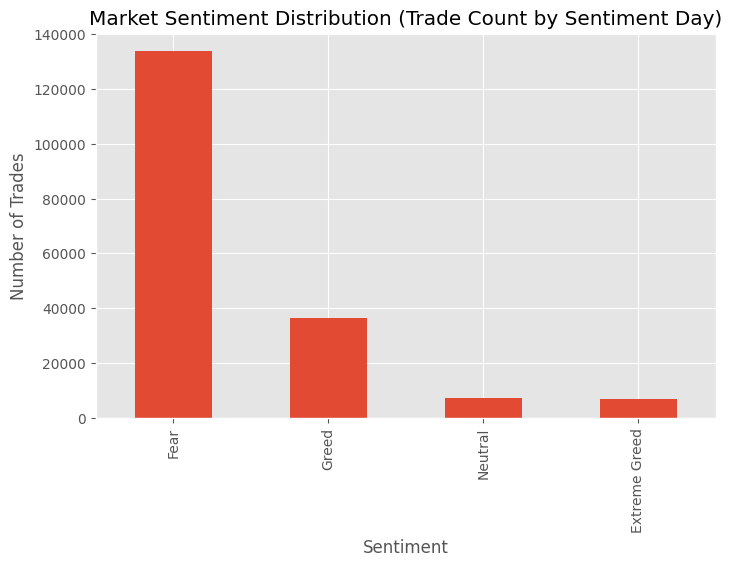

In [14]:
merged_df["Sentiment"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Market Sentiment Distribution (Trade Count by Sentiment Day)")
plt.xlabel("Sentiment")
plt.ylabel("Number of Trades")

plt.show()

**Reading this:** the bulk of trades in this dataset happened on days classified as **Fear**,
with far fewer trades during **Extreme Greed** or **Neutral** days. Keep this imbalance in mind —
averages from small groups (e.g. Extreme Greed) are noisier than averages from Fear, which has
~19x more observations.

### 4.2 PnL by Sentiment

In [15]:
pnl_stats = merged_df.groupby("Sentiment")["Closed PnL"].agg(
    MeanPnL="mean",
    MedianPnL="median",
    StdPnL="std",
    TradeCount="count"
)

# Win rate = share of trades with positive Closed PnL
win_rate = merged_df.groupby("Sentiment")["Closed PnL"].apply(lambda x: (x > 0).mean())
pnl_stats["WinRate"] = win_rate

pnl_stats = pnl_stats.sort_values("MeanPnL", ascending=False)
display(pnl_stats)

,MeanPnL,MedianPnL,StdPnL,TradeCount,WinRate
Sentiment,,,,,
Greed,87.894859,0.0,1148.343968,36289,0.446471
Fear,50.047622,0.0,909.121796,133871,0.415146
Extreme Greed,25.418772,0.0,306.166937,6962,0.490089
Neutral,22.229713,0.0,633.704815,7141,0.317182


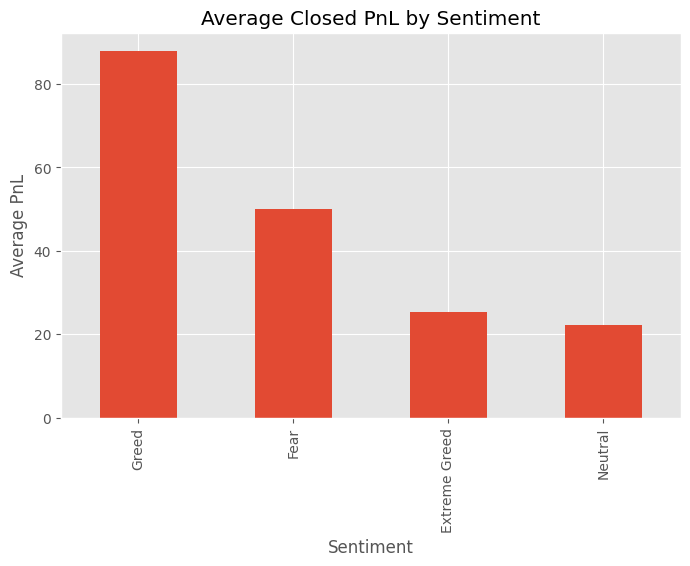

In [16]:
pnl_stats["MeanPnL"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Closed PnL by Sentiment")
plt.ylabel("Average PnL")

plt.show()

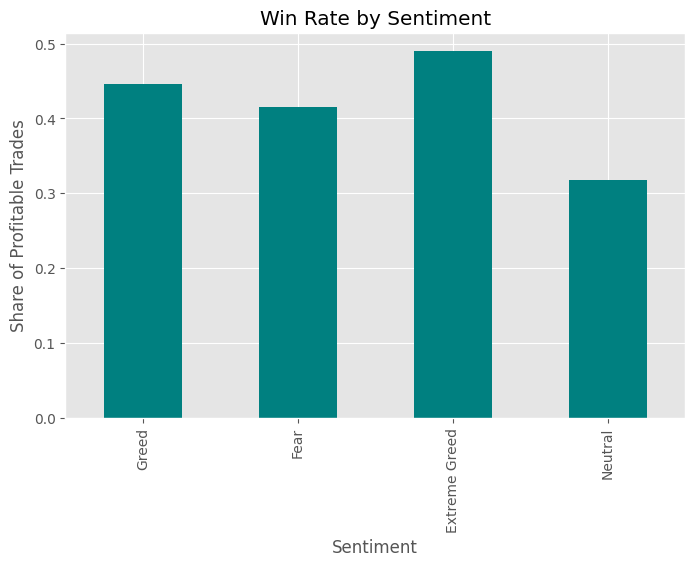

In [17]:
pnl_stats["WinRate"].plot(
    kind="bar",
    figsize=(8,5),
    color="teal"
)

plt.title("Win Rate by Sentiment")
plt.ylabel("Share of Profitable Trades")

plt.show()

**Reading this:** don't rely on the mean alone — check `StdPnL` and `WinRate` alongside it.
A sentiment class can show a high average PnL that's driven by a handful of large winning trades
rather than consistently better trading. Write 1-2 sentences here stating which sentiment class has
the best mean PnL, whether its win rate agrees with that ranking, and whether its standard deviation
suggests high variance (a few big wins/losses) or a genuinely consistent edge.

### 4.3 Statistical Significance: Does Sentiment Actually Affect PnL?

In [18]:
groups = [g["Closed PnL"].values for _, g in merged_df.groupby("Sentiment")]

# Kruskal-Wallis is preferred over one-way ANOVA here since Closed PnL is
# almost certainly not normally distributed (heavy tails from large wins/losses)
h_stat, p_value = stats.kruskal(*groups)

print(f"Kruskal-Wallis H-statistic: {h_stat:.2f}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print("\nResult: statistically significant difference in PnL across sentiment groups (p < 0.05).")
else:
    print("\nResult: no statistically significant difference in PnL across sentiment groups (p >= 0.05).")

Kruskal-Wallis H-statistic: 386.55
p-value: 0.000000

Result: statistically significant difference in PnL across sentiment groups (p < 0.05).


**Reading this:** the earlier bar chart shows the *mean* differs across sentiment groups, but
that alone doesn't confirm the difference is real rather than noise. The Kruskal-Wallis test checks
whether the PnL distributions differ significantly across the sentiment groups as a whole. Report the
p-value here and what it implies for your recommendation — a significant result supports building a
sentiment-aware strategy; a non-significant one means the mean differences are likely just noise.

### 4.4 Long vs. Short Performance

In [19]:
# Side Distribution
merged_df["Side"].value_counts()

Side
SELL    108528
BUY     102696
Name: count, dtype: int64

In [20]:
# Long vs Short Performance
side_pnl = merged_df.groupby("Side")["Closed PnL"].agg(
    MeanPnL="mean",
    WinRate=lambda x: (x > 0).mean()
)

display(side_pnl)

,MeanPnL,WinRate
Side,,
BUY,36.104730,0.273906
SELL,60.713803,0.541243


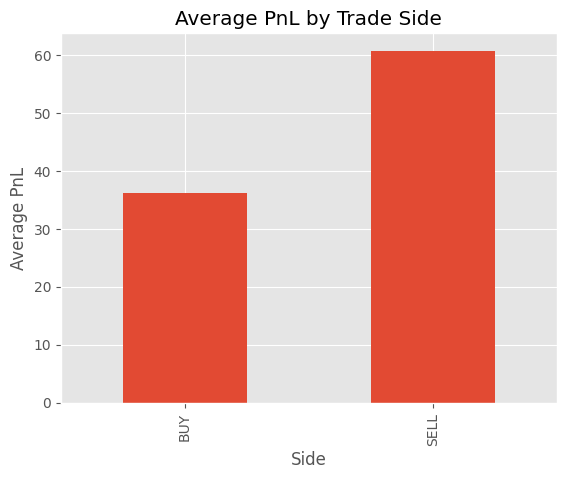

In [21]:
side_pnl["MeanPnL"].plot(kind="bar")

plt.title("Average PnL by Trade Side")
plt.ylabel("Average PnL")

plt.show()

**Reading this:** state plainly whether buyers or sellers came out ahead on average over this
period, and whether that lines up with the overall sentiment mix (e.g. if most trades occurred during
Fear, does one side benefit more from fearful markets?).

### 4.5 Sentiment x Side Interaction

Side,BUY,SELL
Sentiment,,
Extreme Greed,25.578564,25.268770
Fear,58.074630,42.222976
Greed,12.489506,143.617782
Neutral,15.646108,28.576120


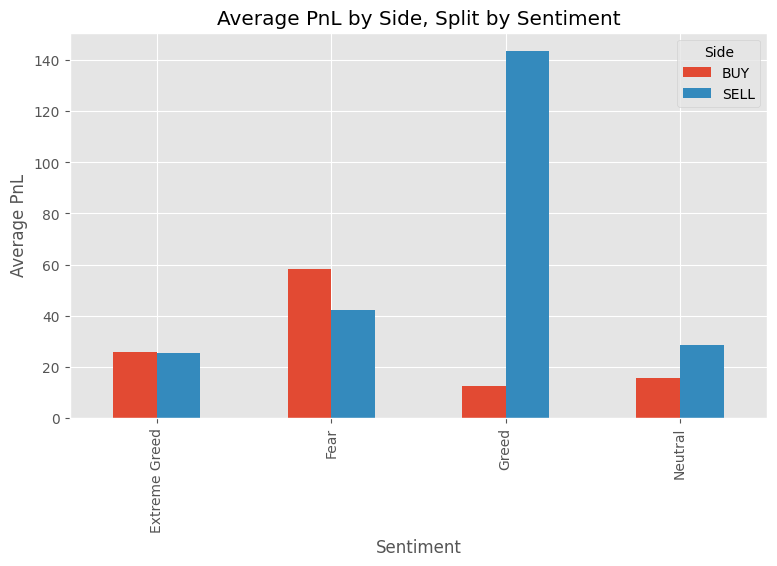

In [22]:
# Does the long/short edge change depending on market sentiment?
side_sentiment_pnl = merged_df.groupby(["Sentiment", "Side"])["Closed PnL"].mean().unstack()
display(side_sentiment_pnl)

side_sentiment_pnl.plot(kind="bar", figsize=(9,5))
plt.title("Average PnL by Side, Split by Sentiment")
plt.ylabel("Average PnL")
plt.show()

**Reading this:** this is the key "actionable strategy" chart — it shows whether going long or
short is better *conditional on* the current sentiment, rather than looking at side and sentiment in
isolation. Call out any sentiment where one side clearly dominates the other.

### 4.6 Coin-Level Performance

In [23]:
# Coin Performance (excluding unresolved '@' coin codes identified earlier)
clean_coin_df = merged_df[~merged_df["Coin"].str.startswith("@")]

coin_pnl = clean_coin_df.groupby("Coin")["Closed PnL"].agg(
    MeanPnL="mean",
    TradeCount="count"
).sort_values("MeanPnL", ascending=False)

display(coin_pnl.head(15))

,MeanPnL,TradeCount
Coin,,
AVAX,239.095613,202
ENA,219.524751,990
EIGEN,197.063189,330
PEOPLE,180.323003,2
DOGE,178.623676,826
SOL,153.358519,10691
MOODENG,151.096714,107
ZRO,148.327509,1239
ETHFI,141.250823,311


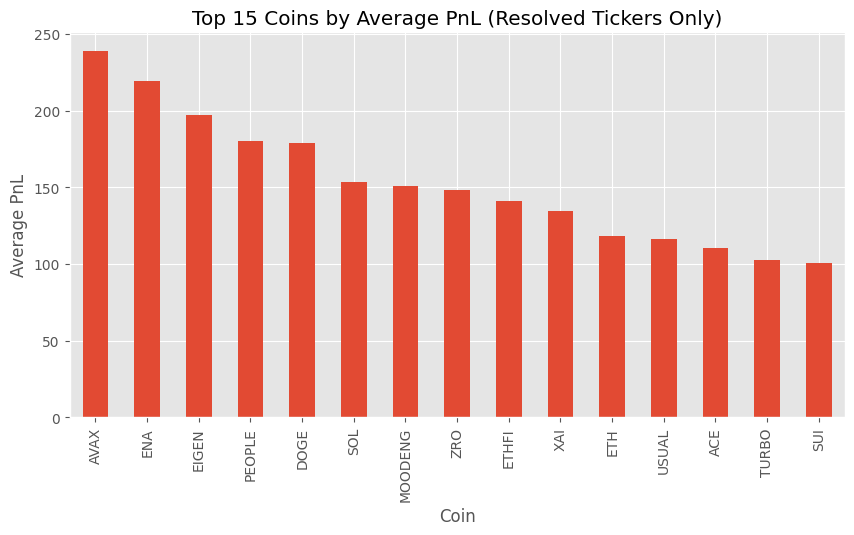

In [24]:
coin_pnl.head(15)["MeanPnL"].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 15 Coins by Average PnL (Resolved Tickers Only)")
plt.ylabel("Average PnL")

plt.show()

**Reading this:** cross-check `TradeCount` before highlighting a coin as a "top performer" —
a coin with 5 trades and a huge average PnL is not the same signal as a coin with 5,000 trades and
a smaller but consistent average PnL.

### 4.7 Top Traders

In [25]:
# Top Traders
top_traders = merged_df.groupby("Account").agg(
    TotalPnL=("Closed PnL", "sum"),
    TotalTrades=("Account", "count"),
    AveragePnL=("Closed PnL", "mean")
)

top_traders = top_traders.sort_values(
    by="TotalPnL",
    ascending=False
)

display(top_traders.head(10))

,TotalPnL,TotalTrades,AveragePnL
Account,,,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2.143383e+06,14733,145.481748
0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,3818,419.127768
0xbaaaf6571ab7d571043ff1e313a9609a10637864,9.401638e+05,21192,44.364091
0x513b8629fe877bb581bf244e326a047b249c4ff1,8.404226e+05,12236,68.684419
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,8.360806e+05,40184,20.806305
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,6.777471e+05,4356,155.589314
0x72743ae2822edd658c0c50608fd7c5c501b2afbd,4.293556e+05,1590,270.034947
0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05,1237,336.735548
0x72c6a4624e1dffa724e6d00d64ceae698af892a0,4.030115e+05,1430,281.826227


**Reading this:** briefly note whether top total-PnL accounts got there through high trade
volume (many small wins) or through a small number of large, high-average-PnL trades — that
distinction matters for whether their approach is replicable.

### 4.8 Correlation Analysis

In [26]:
# Trim to columns that are meaningful for correlation
# (drop IDs / raw timestamps, which have no real numeric meaning)
relevant_cols = [
    "Execution Price", "Size Tokens", "Size USD",
    "Start Position", "Closed PnL", "Fee", "FearGreedValue"
]

corr = merged_df[relevant_cols].corr()
corr

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Fee,FearGreedValue
Execution Price,1.000000,-0.017185,0.189855,0.017241,-0.006505,0.225265,-0.070793
Size Tokens,-0.017185,1.000000,0.013310,0.044660,0.005068,0.006710,0.035295
Size USD,0.189855,0.013310,1.000000,0.007787,0.123589,0.745939,-0.024110
Start Position,0.017241,0.044660,0.007787,1.000000,0.004066,0.010559,0.018870
Closed PnL,-0.006505,0.005068,0.123589,0.004066,1.000000,0.084020,0.011132
Fee,0.225265,0.006710,0.745939,0.010559,0.084020,1.000000,-0.028988
FearGreedValue,-0.070793,0.035295,-0.024110,0.018870,0.011132,-0.028988,1.000000


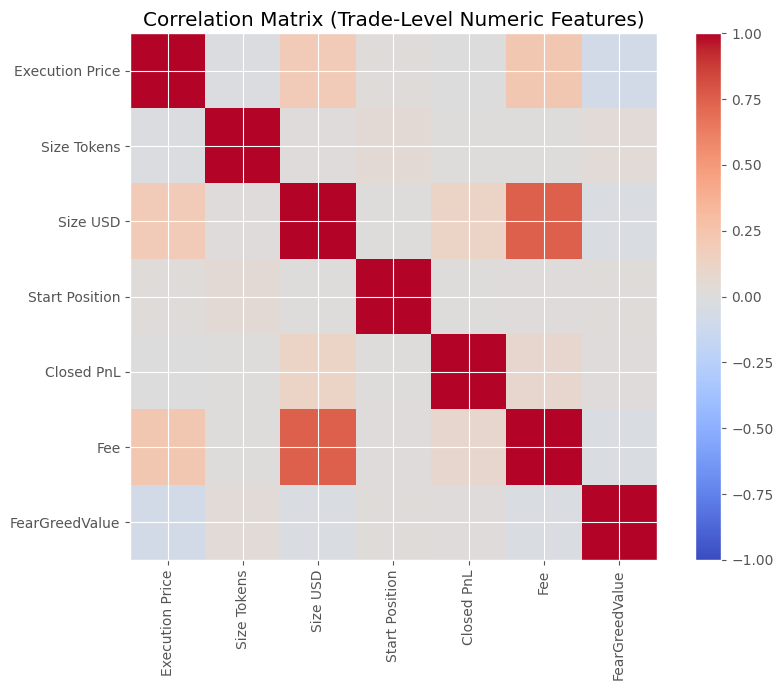

In [27]:
plt.figure(figsize=(9,7))

plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.colorbar()
plt.title("Correlation Matrix (Trade-Level Numeric Features)")

plt.tight_layout()
plt.show()

**Reading this:** identify the one or two strongest correlations with `Closed PnL` and
`FearGreedValue` and state them explicitly — e.g. "Size USD correlates with Fee (expected, fees
scale with trade size) but shows only a weak relationship with Closed PnL, suggesting trade size
alone doesn't predict profitability."**

## 5. Key Findings & Strategy Recommendations

*(Fill this in using the actual numbers from your run — the structure below is a starting template.)*

1. **Sentiment and profitability:** Average Closed PnL is highest during `[X]` sentiment and lowest
   during `[Y]` sentiment. State whether the Kruskal-Wallis test (Section 4.3) confirms this is
   statistically significant, and whether win rate agrees with the mean-PnL ranking.
2. **Long vs. short by sentiment:** State which side (Buy/Sell) performs better overall, and whether
   that edge flips or strengthens under specific sentiment regimes (Section 4.5).
3. **Coin selection:** Name the 2-3 coins with the strongest *and most reliably-sized* (high trade
   count) average PnL from Section 4.6.
4. **Trader concentration:** Note whether PnL is concentrated among a small number of high-volume
   accounts (Section 4.7), which affects how generalizable "top trader" behavior is.
5. **Data limitations:** Mention the unresolved coin codes (`@107` etc.) and the absence of a
   `leverage` field if it wasn't found in Section 3, so the reviewer knows these were considered.

**Suggested strategy takeaway:** one or two sentences translating the above into a concrete rule,
e.g. *"Bias toward [long/short] positions during [sentiment] regimes, and treat [sentiment] days as
higher-variance / lower-conviction periods based on the higher standard deviation observed."*
